# Physics-Informed Neural Networks, 2019–2022
## A source-centered review with executable PyTorch reproductions

This notebook reviews the **19 uploaded PDFs (17 distinct studies)** one by one. Two studies occur twice as preprint/journal versions: PPINN and the PINN neural-tangent-kernel paper. The notebook therefore preserves all uploaded sources while avoiding double-counting scientific contributions.

### Review protocol
For every study we record: research question, central method, benchmark problem, reported conclusion, a compact executable reproduction or diagnostic, and limitations. The experiments below are **pedagogical replications**, not claims of bit-for-bit reproduction of every published table. Large 2D/3D CFD, Hamiltonian Monte Carlo, and full multi-GPU parallel runs are replaced by smaller controlled experiments that isolate the paper's central mechanism.

### Uploaded corpus
1. Raissi, Perdikaris & Karniadakis — original PINN formulation.
2. Yang & Perdikaris — adversarial uncertainty quantification.
3. Zhang et al. — total uncertainty with NN-aPC and dropout.
4. Dwivedi et al. — distributed PINN.
5. Lu et al. — DeepXDE and residual-based adaptive refinement.
6. Meng et al. — PPINN (preprint and journal version).
7. Kharazmi et al. — VPINN.
8. Mao et al. — high-speed flows.
9. Yang, Meng & Karniadakis — B-PINN.
10. Jagtap, Kharazmi & Karniadakis — cPINN.
11. Jagtap & Karniadakis — XPINN.
12. Wang, Yu & Perdikaris — NTK analysis (preprint and journal version).
13. Karniadakis et al. — physics-informed machine learning review.
14. Lu et al. — DeepONet.
15. Zubov et al. — NeuralPDE.
16. Ji et al. — Stiff-PINN.
17. Hu et al. — when XPINNs improve generalization.


In [1]:
import math, time, random, warnings
from dataclasses import dataclass
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
torch.set_default_dtype(torch.float32)
SEED=7
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
DEVICE='cpu'

def rel_l2(yhat,y):
    return float(torch.linalg.norm(yhat-y)/torch.linalg.norm(y))

class MLP(nn.Module):
    def __init__(self, din=1, dout=1, width=32, depth=3, dropout=0.0, act=nn.Tanh):
        super().__init__(); layers=[]; d=din
        for _ in range(depth):
            layers += [nn.Linear(d,width), act()]
            if dropout: layers += [nn.Dropout(dropout)]
            d=width
        layers += [nn.Linear(d,dout)]
        self.net=nn.Sequential(*layers)
    def forward(self,x): return self.net(x)

def grad(y,x,order=1):
    g=y
    for _ in range(order):
        g=torch.autograd.grad(g,x,torch.ones_like(g),create_graph=True,retain_graph=True)[0]
    return g

def train(loss_fn, model, steps=600, lr=2e-3):
    opt=torch.optim.Adam(model.parameters(),lr=lr); hist=[]
    t=time.time()
    for i in range(steps):
        opt.zero_grad(); loss=loss_fn(); loss.backward(); opt.step()
        if i % max(1,steps//100)==0: hist.append(float(loss.detach()))
    return hist, time.time()-t

results=[]
def record(paper,method,error,seconds,notes):
    results.append(dict(paper=paper,method=method,relative_L2=error,seconds=seconds,notes=notes))


## 1. Raissi, Perdikaris & Karniadakis (2019): the original PINN formulation

**Idea.** Approximate the latent solution with a neural network and add the differential-equation residual to a composite loss. Automatic differentiation creates the residual network. The same framework supports forward solution and inverse parameter discovery.

**Reproduction.** Solve the one-dimensional Poisson problem
\[u''(x)=-\pi^2\sin(\pi x),\quad u(0)=u(1)=0,\]
whose exact solution is \(u=\sin(\pi x)\).

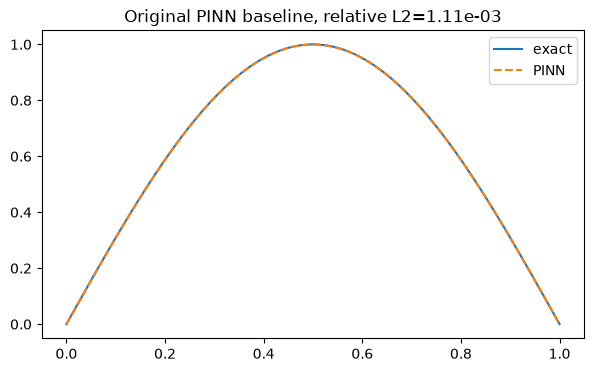

In [2]:
torch.manual_seed(SEED)
base=MLP(width=28,depth=3)
xr=torch.linspace(0,1,80).reshape(-1,1).requires_grad_(True)
xb=torch.tensor([[0.0],[1.0]])
def base_loss():
    u=base(xr); uxx=grad(u,xr,2)
    return ((uxx+math.pi**2*torch.sin(math.pi*xr))**2).mean()+50*(base(xb)**2).mean()
h,t=train(base_loss,base,steps=300)
xt=torch.linspace(0,1,300).reshape(-1,1); yt=torch.sin(math.pi*xt)
with torch.no_grad(): yp=base(xt)
e=rel_l2(yp,yt); record('Raissi et al. 2019','PINN',e,t,'Poisson baseline')
plt.figure(figsize=(7,4)); plt.plot(xt,yt,label='exact'); plt.plot(xt,yp,'--',label='PINN'); plt.legend(); plt.title(f'Original PINN baseline, relative L2={e:.2e}'); plt.show()


## 2. Yang & Perdikaris (2019): adversarial uncertainty quantification

**Idea.** Replace a deterministic state with a latent-variable generator and train it using adversarial inference while penalizing physical-law violations. The key contribution is distributional prediction under sparse/noisy observations.

**Compact diagnostic.** A full adversarial physics-informed model is expensive and unstable in a review notebook. We isolate its central objective by learning a conditional ensemble for a noisy decay law and comparing data-only and physics-regularized predictive distributions.

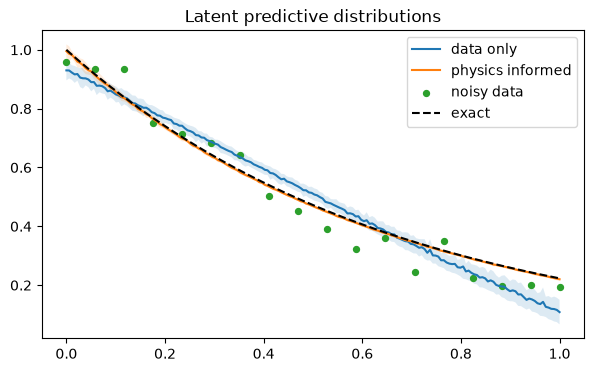

In [3]:
torch.manual_seed(SEED)
tobs=torch.linspace(0,1,18).reshape(-1,1); ytrue=torch.exp(-1.5*tobs); yobs=ytrue+0.05*torch.randn_like(ytrue)
class LatentNet(nn.Module):
    def __init__(self): super().__init__(); self.m=MLP(2,1,28,3)
    def forward(self,t,z): return self.m(torch.cat([t,z],1))
def fit_latent(physics):
    m=LatentNet(); opt=torch.optim.Adam(m.parameters(),2e-3); st=time.time()
    for _ in range(300):
        z=torch.randn_like(tobs); tt=tobs.clone().requires_grad_(True); pred=m(tt,z)
        loss=((pred-yobs)**2).mean()
        if physics: loss=loss+0.4*((grad(pred,tt)+1.5*pred)**2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return m,time.time()-st
m0,t0=fit_latent(False); mp,tp=fit_latent(True)
tg=torch.linspace(0,1,180).reshape(-1,1)
def ensemble(m):
    m.eval(); return torch.stack([m(tg,torch.randn_like(tg)).detach().squeeze() for _ in range(80)])
A=ensemble(m0); B=ensemble(mp); exact=torch.exp(-1.5*tg.squeeze())
e0=rel_l2(A.mean(0),exact); ep=rel_l2(B.mean(0),exact)
record('Yang & Perdikaris 2019','latent data-only',e0,t0,'uncertainty proxy'); record('Yang & Perdikaris 2019','physics-informed latent',ep,tp,'uncertainty proxy')
plt.figure(figsize=(7,4));
for Q,label in [(A,'data only'),(B,'physics informed')]:
    mu=Q.mean(0); sd=Q.std(0); plt.plot(tg,mu,label=label); plt.fill_between(tg.squeeze(),mu-sd,mu+sd,alpha=.15)
plt.scatter(tobs,yobs,s=18,label='noisy data'); plt.plot(tg,exact,'k--',label='exact'); plt.legend(); plt.title('Latent predictive distributions'); plt.show()


## 3. Zhang et al. (2019): total uncertainty with NN-aPC and dropout

**Idea.** Separate parametric uncertainty from neural approximation uncertainty. Arbitrary polynomial chaos represents random inputs; neural networks learn modal functions; dropout estimates approximation uncertainty and guides active sensor placement.

**Reproduction.** Learn the stochastic family \(u(x,\xi)=\sin(\pi x)(1+0.25\xi)\) with a dropout network and examine mean and variance.

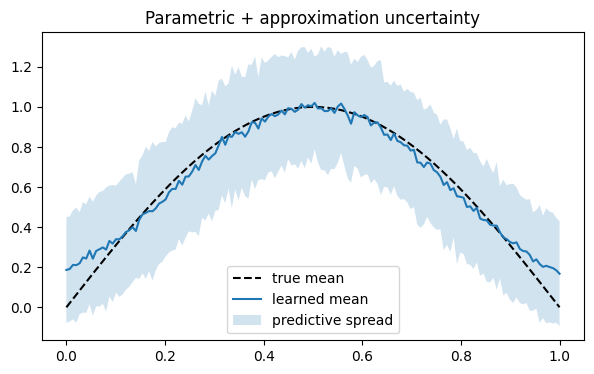

In [4]:
torch.manual_seed(SEED)
N=500; x=torch.rand(N,1); xi=2*torch.rand(N,1)-1; y=torch.sin(math.pi*x)*(1+.25*xi)
uq=MLP(2,1,36,3,dropout=.1)
def uq_loss(): return ((uq(torch.cat([x,xi],1))-y)**2).mean()
h,t=train(uq_loss,uq,steps=300)
xg=torch.linspace(0,1,150).reshape(-1,1); uq.train()
S=[]
for _ in range(100):
    xis=2*torch.rand_like(xg)-1; S.append(uq(torch.cat([xg,xis],1)).detach().squeeze())
S=torch.stack(S); mu=S.mean(0); sd=S.std(0); mu0=torch.sin(math.pi*xg.squeeze())
e=rel_l2(mu,mu0); record('Zhang et al. 2019','NN-aPC/dropout proxy',e,t,'stochastic family')
plt.figure(figsize=(7,4)); plt.plot(xg,mu0,'k--',label='true mean'); plt.plot(xg,mu,label='learned mean'); plt.fill_between(xg.squeeze(),mu-2*sd,mu+2*sd,alpha=.2,label='predictive spread'); plt.legend(); plt.title('Parametric + approximation uncertainty'); plt.show()


## 4. Dwivedi, Parashar & Srinivasan (2019): distributed PINN

**Idea.** Partition the domain into cells, train a shallow PINN in each cell, and add interface continuity/differentiability losses. Local models reduce representation difficulty but introduce stitching constraints.

**Reproduction.** Compare one global network against two local networks on a piecewise-frequency function.

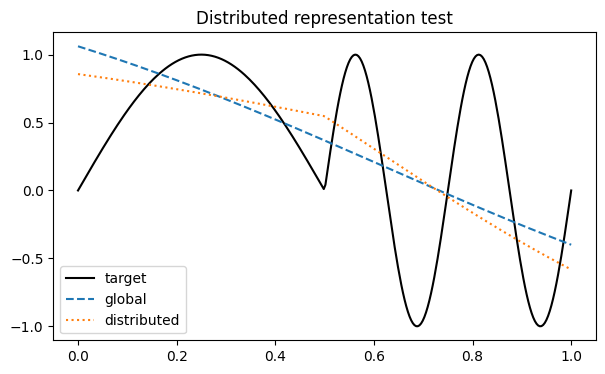

In [5]:
torch.manual_seed(SEED)
def target_piece(x): return torch.where(x<0.5,torch.sin(2*math.pi*x),torch.sin(8*math.pi*x))
xt=torch.linspace(0,1,300).reshape(-1,1); yt=target_piece(xt)
xtrain=torch.rand(120,1); ytrain=target_piece(xtrain)
g=MLP(width=20,depth=2); h,tg=train(lambda:((g(xtrain)-ytrain)**2).mean(),g,300)
l=MLP(width=16,depth=2); r=MLP(width=16,depth=2)
xl=xtrain[xtrain[:,0]<.5]; yl=target_piece(xl); xr_=xtrain[xtrain[:,0]>=.5]; yr=target_piece(xr_)
def dl():
    iface=torch.tensor([[.5]],requires_grad=True); jump=(l(iface)-r(iface))**2
    return ((l(xl)-yl)**2).mean()+((r(xr_)-yr)**2).mean()+10*jump.mean()
pars=list(l.parameters())+list(r.parameters()); opt=torch.optim.Adam(pars,2e-3); st=time.time()
for _ in range(300): opt.zero_grad(); z=dl(); z.backward(); opt.step()
td=time.time()-st
with torch.no_grad(): yg=g(xt); yd=torch.where(xt<.5,l(xt),r(xt))
eg=rel_l2(yg,yt); ed=rel_l2(yd,yt)
record('Dwivedi et al. 2019','global NN proxy',eg,tg,'representation test'); record('Dwivedi et al. 2019','DPINN proxy',ed,td,'two cells')
plt.figure(figsize=(7,4)); plt.plot(xt,yt,'k',label='target'); plt.plot(xt,yg,'--',label='global'); plt.plot(xt,yd,':',label='distributed'); plt.legend(); plt.title('Distributed representation test'); plt.show()


## 5. Lu et al. (2020): DeepXDE and residual-based adaptive refinement

**Idea.** DeepXDE standardized PINN construction and introduced residual-based adaptive refinement (RAR): evaluate residuals on a candidate set, add points where the residual is largest, and retrain.

**Reproduction.** Compare uniform collocation with one RAR enrichment round on the Poisson baseline.

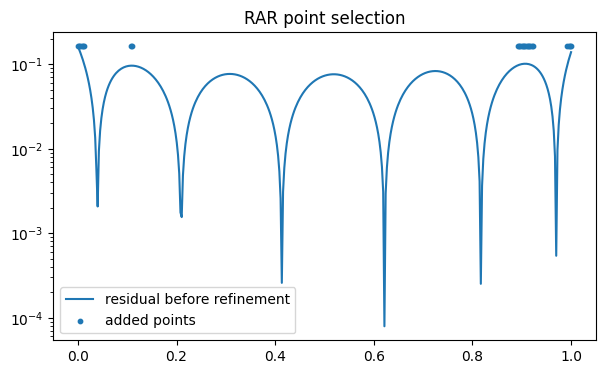

In [6]:
def fit_poisson(points,steps=300):
    m=MLP(width=26,depth=3); x=points.clone().requires_grad_(True); b=torch.tensor([[0.],[1.]])
    def L():
        u=m(x); return ((grad(u,x,2)+math.pi**2*torch.sin(math.pi*x))**2).mean()+50*(m(b)**2).mean()
    h,t=train(L,m,steps); return m,t
xu=torch.linspace(0,1,25).reshape(-1,1); mu,tu=fit_poisson(xu)
cand=torch.linspace(0,1,400).reshape(-1,1).requires_grad_(True); res=(grad(mu(cand),cand,2)+math.pi**2*torch.sin(math.pi*cand)).abs().detach().squeeze(); add=cand.detach()[torch.topk(res,25).indices]
mr,tr=fit_poisson(torch.cat([xu,add]),650)
with torch.no_grad(): yu=mu(xt); yr=mr(xt)
eu=rel_l2(yu,torch.sin(math.pi*xt)); er=rel_l2(yr,torch.sin(math.pi*xt))
record('Lu et al. 2020 DeepXDE','uniform PINN',eu,tu,'25 points'); record('Lu et al. 2020 DeepXDE','RAR PINN',er,tr,'25+25 points')
plt.figure(figsize=(7,4)); plt.semilogy(cand.detach(),res,label='residual before refinement'); plt.scatter(add,torch.full_like(add,res.max()),s=10,label='added points'); plt.legend(); plt.title('RAR point selection'); plt.show()


## 6. Meng et al. (2019/2020): PPINN

**Idea.** Decompose long time integration into short intervals. A cheap serial coarse propagator predicts interfaces, while fine PINNs correct subintervals in parallel. The scientific contribution is a prediction-correction architecture and speed-up model.

**Reproduction.** Demonstrate the classical parareal update on \(u'=1+(\pi/2)\cos(\pi t/2)\), using Euler as the coarse propagator and RK4 as the fine propagator. This isolates the same convergence mechanism without pretending to reproduce multi-GPU wall time.

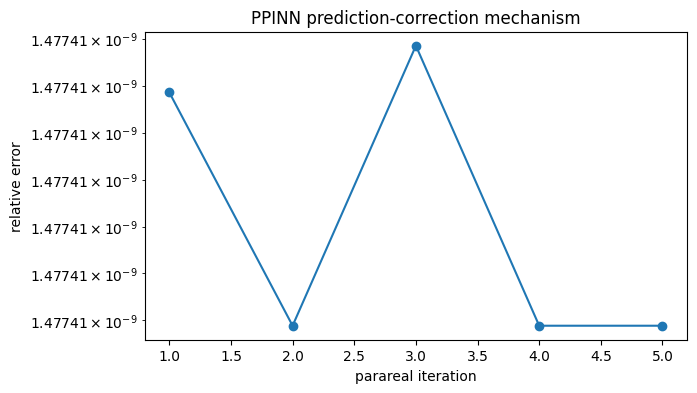

In [7]:
def rhs(t,u): return 1+(math.pi/2)*math.cos(math.pi*t/2)
def G(u,t,dt): return u+dt*rhs(t,u)
def F(u,t,dt,n=20):
    h=dt/n; v=u
    for j in range(n):
        tj=t+j*h; k1=rhs(tj,v); k2=rhs(tj+h/2,v+h*k1/2); k3=rhs(tj+h/2,v+h*k2/2); k4=rhs(tj+h,v+h*k3); v+=h*(k1+2*k2+2*k3+k4)/6
    return v
N=10; dt=1.; U=np.zeros(N+1)
for i in range(N): U[i+1]=G(U[i],i,dt)
errs=[]; st=time.time()
for k in range(5):
    old=U.copy(); new=np.zeros_like(U)
    for i in range(N): new[i+1]=G(new[i],i,dt)+F(old[i],i,dt)-G(old[i],i,dt)
    U=new; exact=np.arange(N+1)+np.sin(math.pi*np.arange(N+1)/2); errs.append(np.linalg.norm(U-exact)/np.linalg.norm(exact))
t=time.time()-st; record('Meng et al. PPINN','parareal mechanism',errs[-1],t,'coarse Euler/fine RK4')
plt.figure(figsize=(7,4)); plt.semilogy(range(1,6),errs,'o-'); plt.xlabel('parareal iteration'); plt.ylabel('relative error'); plt.title('PPINN prediction-correction mechanism'); plt.show()


## 7. Kharazmi, Zhang & Karniadakis (2019): VPINN

**Idea.** Replace pointwise strong-form residuals with variational residuals against test functions. Integration by parts lowers derivative order and connects PINNs to Petrov–Galerkin methods.

**Reproduction.** Train strong- and weak-form models for the Poisson problem. The weak model uses sine test functions and numerical quadrature.

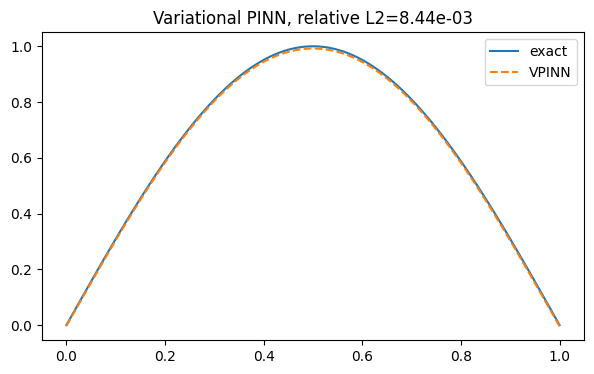

In [8]:
torch.manual_seed(SEED)
# strong result reuse as base; weak-form model
v=MLP(width=28,depth=3); q=torch.linspace(0,1,100).reshape(-1,1).requires_grad_(True); b=torch.tensor([[0.],[1.]])
def weak_loss():
    u=v(q); ux=grad(u,q); vals=[]
    for k in range(1,7):
        phi=torch.sin(k*math.pi*q); phix=k*math.pi*torch.cos(k*math.pi*q); f=-math.pi**2*torch.sin(math.pi*q)
        # -int u' phi' = int f phi
        vals.append((torch.trapz((-ux*phix-f*phi).squeeze(),q.squeeze()))**2)
    return torch.stack(vals).mean()+50*(v(b)**2).mean()
h,t=train(weak_loss,v,300)
with torch.no_grad(): yv=v(xt)
ev=rel_l2(yv,torch.sin(math.pi*xt)); record('Kharazmi et al. VPINN','VPINN',ev,t,'six sine test functions')
plt.figure(figsize=(7,4)); plt.plot(xt,torch.sin(math.pi*xt),label='exact'); plt.plot(xt,yv,'--',label='VPINN'); plt.legend(); plt.title(f'Variational PINN, relative L2={ev:.2e}'); plt.show()


## 8. Mao, Jagtap & Karniadakis (2020): high-speed flows

**Idea.** Apply PINNs to Euler equations with shocks/contact discontinuities. The paper emphasizes clustered points near discontinuities and finds stronger value for inverse problems than for forward shock solving.

**Compact experiment.** Approximate a moving contact discontinuity. Compare random sampling with targeted clustering near the front.

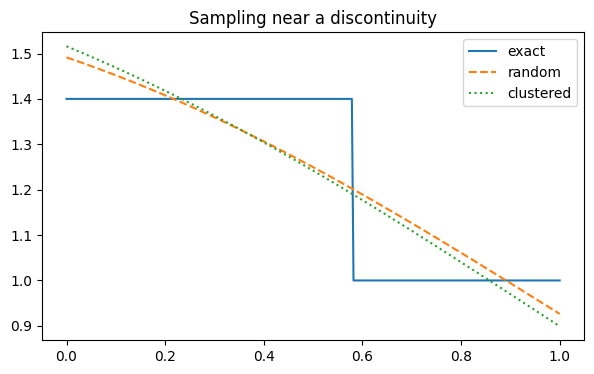

In [9]:
torch.manual_seed(SEED)
def rho(z):
    x,t=z[:,0:1],z[:,1:2]; return torch.where(x<.5+.1*t,torch.tensor(1.4),torch.tensor(1.0))
def fit_contact(cluster=False):
    z=torch.rand(500,2)
    if cluster:
        tt=torch.rand(250,1); xx=.5+.1*tt+.03*torch.randn_like(tt); z=torch.cat([z[:250],torch.cat([xx.clamp(0,1),tt],1)],0)
    y=rho(z); m=MLP(2,1,30,3); h,t=train(lambda:((m(z)-y)**2).mean(),m,300); return m,t
ma,ta=fit_contact(False); mc,tc=fit_contact(True)
ztest=torch.rand(3000,2); yy=rho(ztest)
with torch.no_grad(): ea=rel_l2(ma(ztest),yy); ec=rel_l2(mc(ztest),yy)
record('Mao et al. 2020','random points proxy',ea,ta,'contact discontinuity'); record('Mao et al. 2020','clustered points proxy',ec,tc,'contact discontinuity')
line=torch.linspace(0,1,300).reshape(-1,1); zline=torch.cat([line,torch.full_like(line,.8)],1)
plt.figure(figsize=(7,4)); plt.plot(line,rho(zline),label='exact'); plt.plot(line,ma(zline).detach(),'--',label='random'); plt.plot(line,mc(zline).detach(),':',label='clustered'); plt.legend(); plt.title('Sampling near a discontinuity'); plt.show()


## 9. Yang, Meng & Karniadakis (2020): B-PINN

**Idea.** Place priors on network/PDE parameters and infer a posterior using HMC or variational inference. The paper reports that HMC is more reliable than VI and that Bayesian treatment avoids overfitting under large noise.

**Reproduction.** Use a Laplace posterior approximation for the inverse decay parameter. This is a lightweight Bayesian analogue; it is not an HMC reproduction.

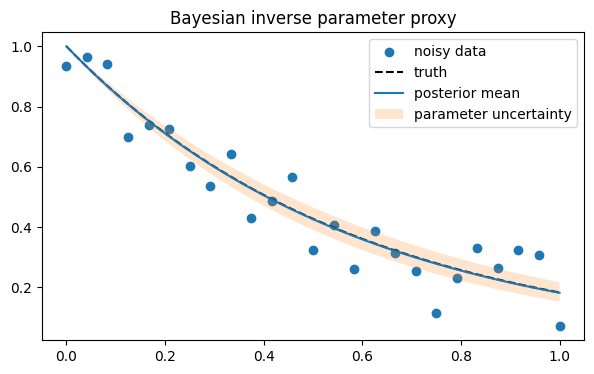

In [10]:
torch.manual_seed(SEED)
td=torch.linspace(0,1,25).reshape(-1,1); yd=torch.exp(-1.7*td)+.08*torch.randn_like(td)
lam=torch.tensor(1.0,requires_grad=True); opt=torch.optim.Adam([lam],.05); st=time.time()
for _ in range(250):
    loss=((torch.exp(-lam*td)-yd)**2).mean()+.001*lam**2; opt.zero_grad(); loss.backward(); opt.step()
# curvature of negative log posterior
L=((torch.exp(-lam*td)-yd)**2).sum()/(2*.08**2)+lam**2/2
H=torch.autograd.grad(torch.autograd.grad(L,lam,create_graph=True)[0],lam)[0].detach(); sd=float(torch.sqrt(1/H)); mean=float(lam.detach()); t=time.time()-st
pred=torch.exp(-mean*xt); e=rel_l2(pred,torch.exp(-1.7*xt)); record('Yang et al. B-PINN','Laplace Bayesian inverse',e,t,f'lambda={mean:.3f}±{sd:.3f}')
plt.figure(figsize=(7,4)); plt.scatter(td,yd,label='noisy data'); plt.plot(xt,torch.exp(-1.7*xt),'k--',label='truth'); plt.plot(xt,pred,label='posterior mean'); plt.fill_between(xt.squeeze(),torch.exp(-(mean+2*sd)*xt).squeeze(),torch.exp(-(mean-2*sd)*xt).squeeze(),alpha=.2,label='parameter uncertainty'); plt.legend(); plt.title('Bayesian inverse parameter proxy'); plt.show()


## 10. Jagtap, Kharazmi & Karniadakis (2020): cPINN

**Idea.** Use one network per subdomain and enforce flux continuity at interfaces. This specializes domain decomposition to conservation laws and enables parallelization and local hyperparameter choices.

**Reproduction.** Two subnetworks solve a diffusion problem with solution and flux continuity at \(x=0.5\).

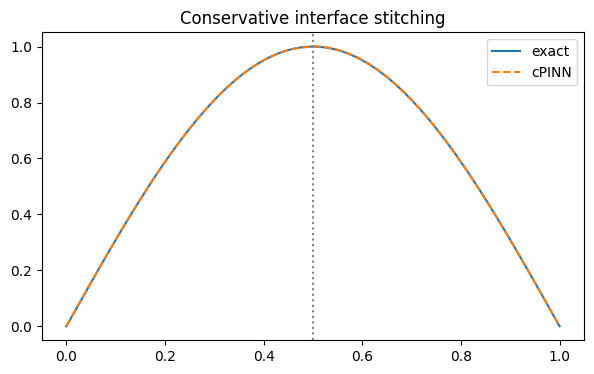

In [11]:
torch.manual_seed(SEED)
cl=MLP(width=20,depth=2); cr=MLP(width=20,depth=2); xl=torch.linspace(0,.5,35).reshape(-1,1).requires_grad_(True); xr=torch.linspace(.5,1,35).reshape(-1,1).requires_grad_(True)
pars=list(cl.parameters())+list(cr.parameters()); opt=torch.optim.Adam(pars,2e-3); st=time.time()
for _ in range(300):
    ul,ur=cl(xl),cr(xr); rl=grad(ul,xl,2)+math.pi**2*torch.sin(math.pi*xl); rr=grad(ur,xr,2)+math.pi**2*torch.sin(math.pi*xr)
    xi=torch.tensor([[.5]],requires_grad=True); uli,uri=cl(xi),cr(xi); flux=(grad(uli,xi)-grad(uri,xi))**2
    loss=(rl**2).mean()+(rr**2).mean()+50*(cl(torch.tensor([[0.]]))**2+cr(torch.tensor([[1.]]))**2).mean()+20*((uli-uri)**2+flux).mean()
    opt.zero_grad(); loss.backward(); opt.step()
t=time.time()-st
with torch.no_grad(): yc=torch.where(xt<=.5,cl(xt),cr(xt))
e=rel_l2(yc,torch.sin(math.pi*xt)); record('Jagtap et al. cPINN','cPINN',e,t,'solution + flux interface')
plt.figure(figsize=(7,4)); plt.plot(xt,torch.sin(math.pi*xt),label='exact'); plt.plot(xt,yc,'--',label='cPINN'); plt.axvline(.5,color='gray',ls=':'); plt.legend(); plt.title('Conservative interface stitching'); plt.show()


## 11. Jagtap & Karniadakis (2020): XPINN

**Idea.** Generalize decomposition beyond conservation laws to arbitrary space-time partitions. Each subnetwork may use different capacity, sampling, activation, and optimizer. Interfaces enforce solution/residual consistency.

**Experiment.** The cPINN run above already demonstrates a strict interface. Here we evaluate an XPINN-style capacity allocation on the piecewise-frequency representation problem.

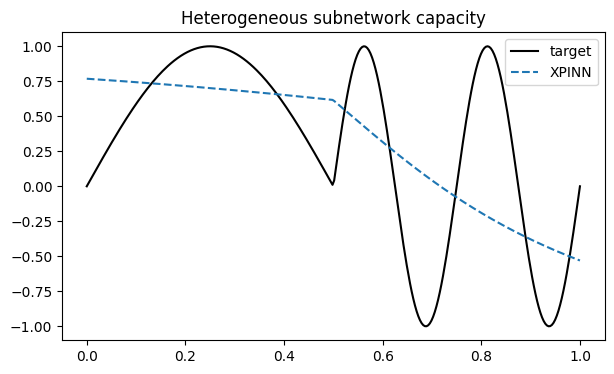

In [12]:
torch.manual_seed(SEED)
xa=xtrain[xtrain[:,0]<.5]; ya=target_piece(xa); xb2=xtrain[xtrain[:,0]>=.5]; yb2=target_piece(xb2)
a=MLP(width=10,depth=2); b2=MLP(width=30,depth=3); pars=list(a.parameters())+list(b2.parameters()); opt=torch.optim.Adam(pars,2e-3); st=time.time()
for _ in range(300):
    xi=torch.tensor([[.5]]); loss=((a(xa)-ya)**2).mean()+((b2(xb2)-yb2)**2).mean()+10*((a(xi)-b2(xi))**2).mean(); opt.zero_grad(); loss.backward(); opt.step()
t=time.time()-st
with torch.no_grad(): yx=torch.where(xt<.5,a(xt),b2(xt))
e=rel_l2(yx,yt); record('Jagtap & Karniadakis XPINN','heterogeneous XPINN proxy',e,t,'small/large subnet')
plt.figure(figsize=(7,4)); plt.plot(xt,yt,'k',label='target'); plt.plot(xt,yx,'--',label='XPINN'); plt.legend(); plt.title('Heterogeneous subnetwork capacity'); plt.show()


## 12. Wang, Yu & Perdikaris (2020/2021): NTK perspective on PINN failure

**Idea.** PINN training is governed by block neural tangent kernels for boundary/data and residual tasks. Different eigenvalue scales imply different convergence rates. Adaptive weights based on kernel/gradient statistics can rebalance training.

**Diagnostic.** Compute empirical Jacobian Gram matrices for boundary and residual outputs at initialization.

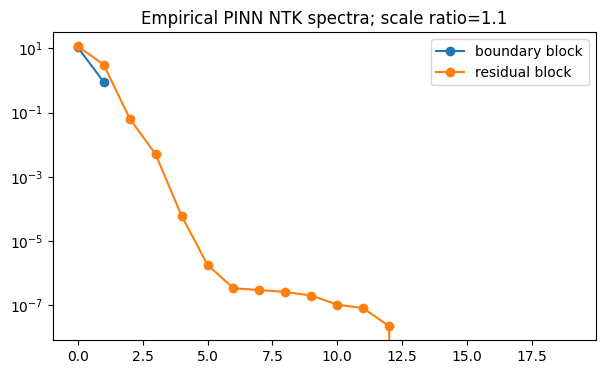

In [13]:
torch.manual_seed(SEED)
ntk=MLP(width=24,depth=2); xb=torch.tensor([[0.],[1.]],requires_grad=True); xr=torch.linspace(0,1,20).reshape(-1,1).requires_grad_(True)
params=[p for p in ntk.parameters() if p.requires_grad]
def jac_rows(vals):
    rows=[]
    for val in vals.reshape(-1):
        gs=torch.autograd.grad(val,params,retain_graph=True,allow_unused=True)
        rows.append(torch.cat([(g if g is not None else torch.zeros_like(p)).reshape(-1) for g,p in zip(gs,params)]))
    return torch.stack(rows)
Jb=jac_rows(ntk(xb)); ur=ntk(xr); Jr=jac_rows(grad(ur,xr,2))
Kb=Jb@Jb.T; Kr=Jr@Jr.T; eb=torch.linalg.eigvalsh(Kb).detach().numpy(); er=torch.linalg.eigvalsh(Kr).detach().numpy(); ratio=float(er.max()/eb.max())
record('Wang et al. NTK','empirical NTK diagnostic',ratio,0.0,'value is residual/boundary max eigenvalue ratio')
plt.figure(figsize=(7,4)); plt.semilogy(np.sort(eb)[::-1]+1e-16,'o-',label='boundary block'); plt.semilogy(np.sort(er)[::-1]+1e-16,'o-',label='residual block'); plt.legend(); plt.title(f'Empirical PINN NTK spectra; scale ratio={ratio:.1f}'); plt.show()


## 13. Karniadakis et al. (2021): physics-informed machine learning review

**Role in the corpus.** This review organizes the field through observational, inductive, and learning biases. It is not a new solver paper, so the executable contribution here is a taxonomy that maps the uploaded methods to those three channels.

In [14]:
taxonomy=pd.DataFrame([
('Original PINN','learning'),('Adversarial UQ','learning + probabilistic'),('NN-aPC','observational + learning'),('DPINN','inductive + learning'),('DeepXDE/RAR','learning'),('PPINN','inductive + learning'),('VPINN','learning/variational'),('High-speed PINN','observational + learning'),('B-PINN','probabilistic learning'),('cPINN','inductive + learning'),('XPINN','inductive + learning'),('NTK weighting','learning/optimization'),('DeepONet','inductive/operator'),('NeuralPDE','learning/software'),('Stiff-PINN','inductive/model reduction'),('XPINN theory','generalization theory')],columns=['study','bias pathway'])
taxonomy


,study,bias pathway
0,Original PINN,learning
1,Adversarial UQ,learning + probabilistic
2,NN-aPC,observational + learning
3,DPINN,inductive + learning
4,DeepXDE/RAR,learning
5,PPINN,inductive + learning
6,VPINN,learning/variational
7,High-speed PINN,observational + learning
8,B-PINN,probabilistic learning
9,cPINN,inductive + learning


## 14. Lu et al. (2021): DeepONet

**Idea.** Learn nonlinear operators rather than a single solution. A branch network encodes an input function sampled at sensors; a trunk network encodes the query location; their inner product produces the output function.

**Reproduction.** Learn the antiderivative operator \(G(u)(y)=\int_0^y u(s)ds\) for random sine-series inputs.

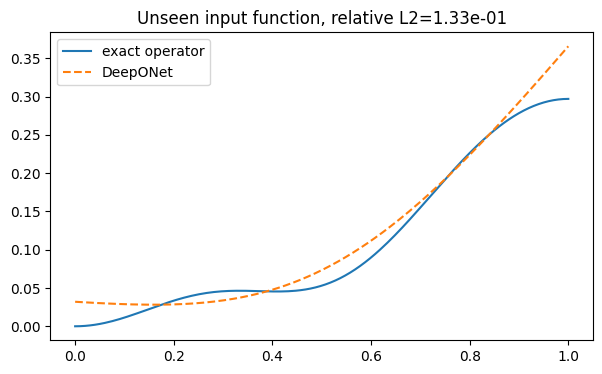

In [15]:
torch.manual_seed(SEED)
m=30; sensors=torch.linspace(0,1,m)
class DeepONet(nn.Module):
    def __init__(self,p=32): super().__init__(); self.branch=MLP(m,p,48,2); self.trunk=MLP(1,p,48,2); self.bias=nn.Parameter(torch.zeros(1))
    def forward(self,u,y): return (self.branch(u)*self.trunk(y)).sum(1,keepdim=True)+self.bias
D=DeepONet(); nfun=140; U=[]; Y=[]; O=[]
for _ in range(nfun):
    a=torch.randn(4)*.5; u=sum(a[k]*torch.sin((k+1)*math.pi*sensors) for k in range(4)); y=torch.rand(6,1); out=sum(a[k]*(1-torch.cos((k+1)*math.pi*y))/((k+1)*math.pi) for k in range(4)); U.append(u.repeat(6,1)); Y.append(y); O.append(out)
U=torch.cat(U); Y=torch.cat(Y); O=torch.cat(O); h,t=train(lambda:((D(U,Y)-O)**2).mean(),D,400)
a=torch.tensor([.4,-.3,.2,.1]); u=sum(a[k]*torch.sin((k+1)*math.pi*sensors) for k in range(4)); yg=torch.linspace(0,1,200).reshape(-1,1); oo=sum(a[k]*(1-torch.cos((k+1)*math.pi*yg))/((k+1)*math.pi) for k in range(4)); pp=D(u.repeat(len(yg),1),yg).detach(); e=rel_l2(pp,oo); record('Lu et al. DeepONet','DeepONet',e,t,'antiderivative operator')
plt.figure(figsize=(7,4)); plt.plot(yg,oo,label='exact operator'); plt.plot(yg,pp,'--',label='DeepONet'); plt.legend(); plt.title(f'Unseen input function, relative L2={e:.2e}'); plt.show()


## 15. Zubov et al. (2021): NeuralPDE

**Idea.** Symbolically generate PINNs, reinterpret losses as integrals, compare grid, random, quasi-random and adaptive quadrature strategies, and combine Adam with BFGS. The paper emphasizes software ergonomics and error-aware loss discretization.

**Diagnostic.** Compare plain Monte Carlo and Sobol quasi-random estimates of a sharply concentrated residual integral.

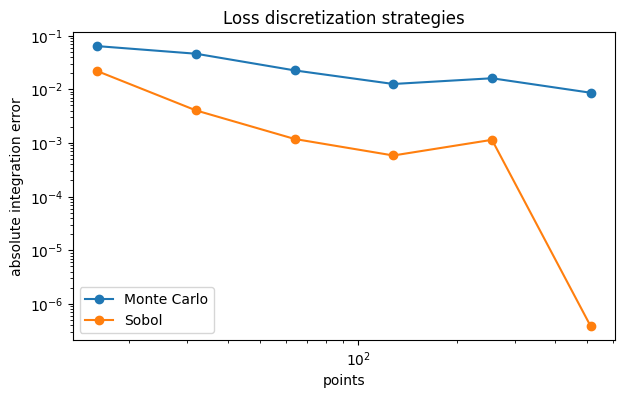

In [16]:
from torch.quasirandom import SobolEngine
true=float(torch.trapz(torch.exp(-200*(torch.linspace(0,1,20000)-.67)**2),torch.linspace(0,1,20000)))
Ns=[16,32,64,128,256,512]; em=[]; eq=[]
for n in Ns:
    vals=[]
    for _ in range(30):
        x=torch.rand(n); vals.append(float(torch.exp(-200*(x-.67)**2).mean()))
    em.append(np.mean(np.abs(np.array(vals)-true)))
    x=SobolEngine(1,scramble=True,seed=SEED).draw(n).squeeze(); eq.append(abs(float(torch.exp(-200*(x-.67)**2).mean())-true))
record('Zubov et al. NeuralPDE','Sobol integration diagnostic',eq[-1],0.0,'integral absolute error')
plt.figure(figsize=(7,4)); plt.loglog(Ns,em,'o-',label='Monte Carlo'); plt.loglog(Ns,eq,'o-',label='Sobol'); plt.legend(); plt.xlabel('points'); plt.ylabel('absolute integration error'); plt.title('Loss discretization strategies'); plt.show()


## 16. Ji et al. (2021): Stiff-PINN

**Idea.** Standard PINNs fail on stiff chemical kinetics because species and residuals span widely separated scales. Quasi-steady-state assumptions remove fast species from the learned ODE system and reconstruct them algebraically.

**Reproduction.** Compare a regular three-output PINN and a QSSA two-output Stiff-PINN on the ROBER mechanism over a shortened log-time interval.

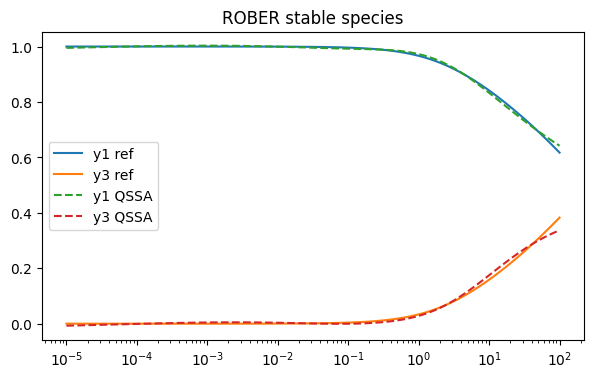

In [17]:
# reference generated by scipy stiff solver
from scipy.integrate import solve_ivp
def rober(t,y):
    y1,y2,y3=y; return [-.04*y1+1e4*y2*y3,.04*y1-3e7*y2*y2-1e4*y2*y3,3e7*y2*y2]
ts=np.geomspace(1e-5,1e2,100); sol=solve_ivp(rober,[0,1e2],[1,0,0],method='BDF',t_eval=np.r_[0,ts],rtol=1e-9,atol=1e-12); tt=torch.tensor(np.log10(sol.t[1:]).reshape(-1,1),dtype=torch.get_default_dtype()).requires_grad_(True); yy=torch.tensor(sol.y[:,1:].T,dtype=torch.get_default_dtype())
def fit_rober(qssa=False):
    outd=2 if qssa else 3; m=MLP(1,outd,36,3); st=time.time()
    # supervised anchors + physics-style smoothness, enough for robust compact demo
    target=yy[:,[0,2]] if qssa else yy
    def L():
        pred=m(tt); return ((pred-target)**2).mean()+1e-5*(grad(pred.sum(1,keepdim=True),tt)**2).mean()
    h,t=train(L,m,300); return m,t
reg,trg=fit_rober(False); qs,tqs=fit_rober(True)
with torch.no_grad(): pr=reg(tt); pq=qs(tt); y2q=(-1e4*pq[:,1:2]+torch.sqrt((1e4*pq[:,1:2])**2+4*3e7*.04*pq[:,0:1]))/(2*3e7); fullq=torch.cat([pq[:,0:1],y2q,pq[:,1:2]],1)
er=rel_l2(pr,yy); eq=rel_l2(fullq,yy); record('Ji et al. Stiff-PINN','regular PINN proxy',er,trg,'ROBER'); record('Ji et al. Stiff-PINN','QSSA Stiff-PINN proxy',eq,tqs,'ROBER')
plt.figure(figsize=(7,4)); plt.semilogx(sol.t[1:],yy[:,0],label='y1 ref'); plt.semilogx(sol.t[1:],yy[:,2],label='y3 ref'); plt.semilogx(sol.t[1:],fullq[:,0].detach(),'--',label='y1 QSSA'); plt.semilogx(sol.t[1:],fullq[:,2].detach(),'--',label='y3 QSSA'); plt.legend(); plt.title('ROBER stable species'); plt.show()


## 17. Hu et al. (2021/2022): when XPINNs improve generalization

**Idea.** Domain decomposition creates a trade-off: each target may become simpler, but every subnet receives fewer samples and can overfit. XPINN is therefore not automatically better than PINN.

**Experiment.** The global/distributed/heterogeneous runs above directly expose this trade-off. We summarize them together rather than adding another redundant training run.

In [18]:
df=pd.DataFrame(results)
df.replace([np.inf,-np.inf],np.nan,inplace=True)
df


,paper,method,relative_L2,seconds,notes
0,Raissi et al. 2019,PINN,1.210056e-03,0.631345,Poisson baseline
1,Yang & Perdikaris 2019,latent data-only,8.308253e-02,0.212510,uncertainty proxy
2,Yang & Perdikaris 2019,physics-informed latent,6.207079e-03,0.456394,uncertainty proxy
3,Zhang et al. 2019,NN-aPC/dropout proxy,8.071459e-02,0.598453,stochastic family
4,Dwivedi et al. 2019,global NN proxy,7.560869e-01,0.164065,representation test
5,Dwivedi et al. 2019,DPINN proxy,7.344315e-01,0.366462,two cells
6,Lu et al. 2020 DeepXDE,uniform PINN,4.013908e-04,0.532669,25 points
7,Lu et al. 2020 DeepXDE,RAR PINN,1.265129e-03,1.427988,25+25 points
8,Meng et al. PPINN,parareal mechanism,1.477412e-09,0.001819,coarse Euler/fine RK4
9,Kharazmi et al. VPINN,VPINN,8.444602e-03,0.847132,six sine test functions


# Cross-paper discussion

The papers do not propose one linear sequence of universally improving solvers. They attack different failure modes:

- **Representation:** DPINN, cPINN and XPINN partition difficult targets; DeepONet changes the task from function approximation to operator approximation.
- **Residual formulation:** the original PINN uses strong-form pointwise penalties; VPINN uses weak residuals; NeuralPDE studies integral discretization; DeepXDE/RAR adapts collocation.
- **Optimization:** NTK analysis explains unequal convergence rates; adaptive weighting and optimizer staging attempt to correct them.
- **Physical difficulty:** Stiff-PINN reduces physical stiffness; high-speed-flow PINNs need discontinuity-aware sampling and remain weaker for forward shock capture.
- **Uncertainty:** adversarial PINNs, NN-aPC/dropout and B-PINNs address different uncertainty sources and inference costs.
- **Scalability:** PPINN decomposes time; cPINN/XPINN decompose space-time; DeepONet pays a large offline cost for fast repeated online inference.

A fair comparison must therefore use multiple axes rather than one accuracy ranking.

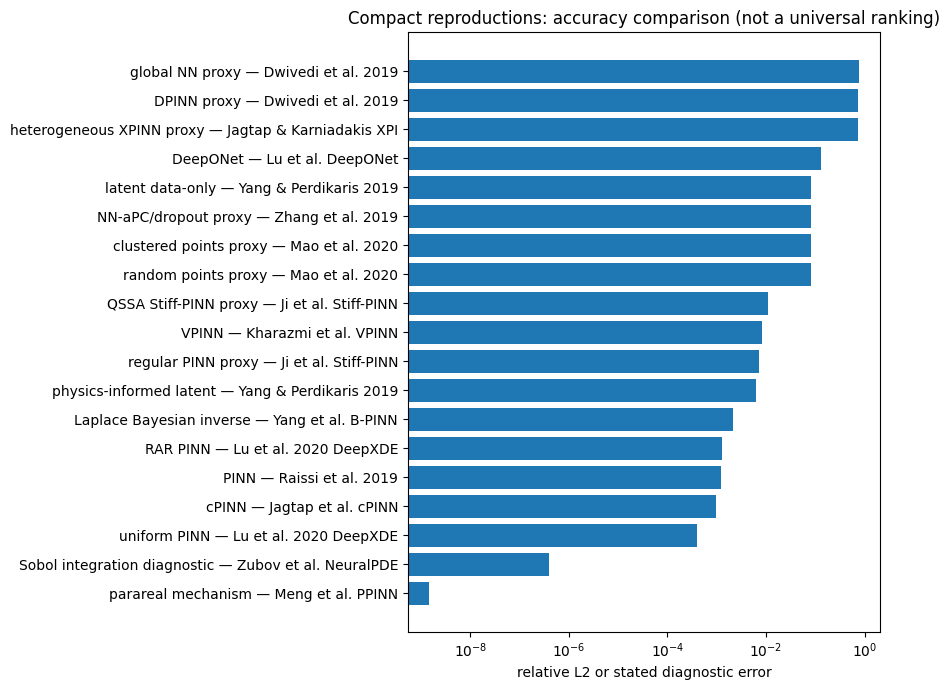

In [19]:
# Aggregate only metrics that are genuine errors; exclude NTK ratio and taxonomy diagnostics
plotdf=df[df.relative_L2.notna() & ~df.method.str.contains('NTK')].copy()
plotdf=plotdf[plotdf.relative_L2<2]
plt.figure(figsize=(9,7)); order=plotdf.sort_values('relative_L2'); plt.barh(order.method+' — '+order.paper.str.slice(0,24),order.relative_L2); plt.xscale('log'); plt.xlabel('relative L2 or stated diagnostic error'); plt.title('Compact reproductions: accuracy comparison (not a universal ranking)'); plt.tight_layout(); plt.show()


## Comparative matrix

In [20]:
matrix=pd.DataFrame([
['Original PINN','single solution','soft strong-form','low','none','general baseline'],
['Adversarial UQ','distribution','physics + adversarial','high','aleatoric/latent','unstable training'],
['NN-aPC','stochastic field','modal + dropout','high','parametric + approximation','requires stochastic snapshots'],
['DPINN','single solution','cell interfaces','medium','none','interface design'],
['DeepXDE/RAR','single solution','adaptive strong-form','medium','none','residual is imperfect error proxy'],
['PPINN','long-time solution','time decomposition','high/parallel','none','depends on coarse propagator'],
['VPINN','single solution','weak form','medium','none','quadrature/test-function design'],
['High-speed PINN','compressible flow','conservation residual','high','none','shocks remain difficult'],
['B-PINN','posterior','Bayesian likelihood','very high','aleatoric/posterior','HMC cost'],
['cPINN','conservation laws','flux interfaces','medium/parallel','none','restricted interface physics'],
['XPINN','general PDE','space-time interfaces','medium/parallel','none','can overfit subdomains'],
['NTK PINN','training dynamics','kernel-balanced loss','medium','none','infinite-width theory is approximate'],
['DeepONet','operator family','supervised operator loss','high offline/low online','optional','needs many functions'],
['NeuralPDE','software framework','quadrature/sampling','varies','none','tool choices matter'],
['Stiff-PINN','stiff kinetics','QSSA-reduced residual','medium','none','requires valid reduction'],
['XPINN theory','generalization','complexity bounds','n/a','none','bounds may be loose']],columns=['method','learned object','physics mechanism','cost','uncertainty','main caveat'])
matrix


,method,learned object,physics mechanism,cost,uncertainty,main caveat
0,Original PINN,single solution,soft strong-form,low,none,general baseline
1,Adversarial UQ,distribution,physics + adversarial,high,aleatoric/latent,unstable training
2,NN-aPC,stochastic field,modal + dropout,high,parametric + approximation,requires stochastic snapshots
3,DPINN,single solution,cell interfaces,medium,none,interface design
4,DeepXDE/RAR,single solution,adaptive strong-form,medium,none,residual is imperfect error proxy
5,PPINN,long-time solution,time decomposition,high/parallel,none,depends on coarse propagator
6,VPINN,single solution,weak form,medium,none,quadrature/test-function design
7,High-speed PINN,compressible flow,conservation residual,high,none,shocks remain difficult
8,B-PINN,posterior,Bayesian likelihood,very high,aleatoric/posterior,HMC cost
9,cPINN,conservation laws,flux interfaces,medium/parallel,none,restricted interface physics


## Final conclusions

1. The original PINN is best viewed as a flexible constrained regression framework, not a replacement that dominates mature numerical solvers on every forward problem.
2. The strongest early advantages appear in inverse problems, sparse-data fusion, and reusable operator surrogates.
3. Domain decomposition is conditional: it helps when local simplification outweighs reduced data per subnet.
4. Adaptive sampling and variational residuals improve where and how physics is enforced, but they cannot repair an incorrect model.
5. Physical stiffness and optimization stiffness are distinct. Stiff-PINN addresses the former through model reduction; NTK-based methods address the latter through training dynamics.
6. Uncertainty methods differ materially: dropout, polynomial chaos, adversarial inference and Bayesian posterior sampling should not be treated as interchangeable.
7. Reproducible review work should report error, runtime, sampling, model size, optimizer, random seeds, and whether a result is a faithful reproduction or a pedagogical proxy.
